# Seasonal Charge/Discharge Decisions, Net-Signed

Average realised battery action by hour of day, one bar per season, one panel per
forecaster family, one figure per market (single-price, dual-price) -- built purely from
data already collected in `8_testing/results/raw_daily/` + `8_testing/results/cross_eval/`
(each row already stores `p_ch_r`/`p_dis_r`, the realised post-saturation charge/discharge
power, and `soc`, the realised state of charge, for all 24 settlement hours of that day,
from the full-robust deployment formulation). No new LP solving or model forward passes
needed.

**Net-signed convention**: bars are `net = p_ch_r - p_dis_r` (MW), positive = net
charging, negative = net discharging, zero line marked for reference. This collapses
charge and discharge into a single bar per hour to keep each panel readable at the cost of
not separately showing gross charge/discharge magnitude -- e.g. a season with heavy
simultaneous cycling (large `p_ch_r` and `p_dis_r` both sizeable within the same hour,
unusual but possible under the robust formulation) would show a small net bar
indistinguishable from genuine idleness. A butterfly-style (separate signed
charge-above/discharge-below axes) alternative exists if that distinction turns out to
matter. Overlaid on each panel (secondary right-hand axis) is the average realised state
of charge `soc` (MWh) as a line, so the accumulation/depletion driving each bar pattern is
visible directly alongside it.

Same native + cross-eval structure as `economic_results.ipynb`: each DFL arm is native in
one market's figure and cross-evaluated in the other (its checkpoint's quantiles run
through the *other* mode's full-robust decision problem and settlement); Baseline and the
CRPS-only Control are price-agnostic, so they appear natively in both. N=5 seed mean +/-
std for the three retrained families (hierarchical: per-seed seasonal-mean profile first,
then mean/std across seeds) -- shown as error bars on the net-charge bars and as shading
on the SOC line; Baseline is a single fixed checkpoint (n=1, no error bars/shading).

## Setup

In [1]:
from __future__ import annotations
import re
import sys
from pyprojroot import here
sys.path.insert(0, str(here() / "8_testing"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from eval_raw import RAW_DAILY_DIR

CROSS_EVAL_DIR = here() / "8_testing" / "results" / "cross_eval"
SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]
DEFAULT_SEED = 20240801
FAMILY_ORDER = ["Baseline", "Control", "DFL Single-price", "DFL Dual-price"]
FAMILY_COLORS = {"Baseline": "C0", "Control": "grey", "DFL Single-price": "C6", "DFL Dual-price": "C3"}
MARKETS = ["single-price", "dual-price"]
SEASON_MONTHS = {"winter": [12, 1, 2], "spring": [3, 4, 5], "summer": [6, 7, 8], "autumn": [9, 10, 11]}
SEASON_ORDER = ["spring", "summer", "autumn", "winter"]
SEASON_COLORS = {"spring": "C2", "summer": "C1", "autumn": "C5", "winter": "C0"}

pd.set_option("display.width", 160)

### Load and label

Same `family`/`seed`/`market` derivation as `economic_results.ipynb`. Season is derived
from each row's `date` (meteorological definition, matching every other seasonal
breakdown this session).

In [2]:
def family_of(base_id: str) -> str:
    if base_id == "baseline":
        return "Baseline"
    if base_id.startswith("crps_only_retrained"):
        return "Control"
    if base_id.startswith("dfl_1stage_single-price"):
        return "DFL Single-price"
    if base_id.startswith("dfl_1stage_dual-price"):
        return "DFL Dual-price"
    raise ValueError(f"unrecognised forecaster_id base: {base_id!r}")


def seed_of(forecaster_id: str) -> int:
    m = re.search(r"_seed(\d+)", forecaster_id)
    return int(m.group(1)) if m else DEFAULT_SEED


def month_to_season(month: int) -> str:
    for season, months in SEASON_MONTHS.items():
        if month in months:
            return season
    raise ValueError(month)


KEEP_COLS = ["forecaster_id", "price_mode", "day", "date", "p_ch_r", "p_dis_r", "soc"]

native = pd.read_parquet(RAW_DAILY_DIR, columns=KEEP_COLS)
cross = pd.read_parquet(CROSS_EVAL_DIR, columns=KEEP_COLS)
all_df = pd.concat([native, cross], ignore_index=True)

all_df["base_id"] = all_df["forecaster_id"].str.replace(r"_ON_(single|dual)-price$", "", regex=True)
all_df["family"] = all_df["base_id"].apply(family_of)
all_df["seed"] = all_df["base_id"].apply(seed_of)
all_df["market"] = all_df["price_mode"]
all_df["month"] = pd.to_datetime(all_df["date"]).dt.month
all_df["season"] = all_df["month"].apply(month_to_season)
all_df["net"] = all_df.apply(lambda r: r["p_ch_r"] - r["p_dis_r"], axis=1)

print(f"all_df: {len(all_df)} rows | families: {sorted(all_df['family'].unique())} | "
      f"markets: {sorted(all_df['market'].unique())}")
print(all_df.groupby(["market", "family", "season"]).agg(n_seeds=("seed", "nunique"), n_days=("day", "size")))

all_df: 11712 rows | families: ['Baseline', 'Control', 'DFL Dual-price', 'DFL Single-price'] | markets: ['dual-price', 'single-price']
                                      n_seeds  n_days
market       family           season                 
dual-price   Baseline         autumn        1      91
                              spring        1      92
                              summer        1      92
                              winter        1      91
             Control          autumn        5     455
                              spring        5     460
                              summer        5     460
                              winter        5     455
             DFL Dual-price   autumn        5     455
                              spring        5     460
                              summer        5     460
                              winter        5     455
             DFL Single-price autumn        5     455
                              spring        5     460
 

### Collection

Hierarchical seed-averaging, matching `seasonal_forecast_shape.ipynb`'s convention: for
each forecaster-seed, average `net` and `soc` (each (24,)) across all days in that season
first (one profile per seed per season), then take mean/std of those per-seed profiles
across seeds (N=5) for the three retrained families. Baseline has a single fixed
checkpoint (n=1, no std).

In [3]:
def seasonal_profiles(market: str, family: str, seed: int):
    """season -> {"net": (24,), "soc": (24,), "ch": (24,), "dis": (24,)} mean profiles for
    this market/family/seed, averaged over that season's test days."""
    sub = all_df[(all_df["market"] == market) & (all_df["family"] == family) & (all_df["seed"] == seed)]
    out = {}
    for season in SEASON_ORDER:
        rows = sub.loc[sub["season"] == season]
        out[season] = {
            "net": np.stack(rows["net"].to_numpy()).mean(axis=0),
            "soc": np.stack(rows["soc"].to_numpy()).mean(axis=0),
            "ch": np.stack(rows["p_ch_r"].to_numpy()).mean(axis=0),
            "dis": np.stack(rows["p_dis_r"].to_numpy()).mean(axis=0),
        }
    return out


RESULTS = {}   # (market, family) -> {season: {"net"/"soc"/"ch"/"dis": (mean, std|None)}}
for market in MARKETS:
    for family in FAMILY_ORDER:
        seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
        per_seed = [seasonal_profiles(market, family, seed) for seed in seeds]
        RESULTS[(market, family)] = {}
        for season in SEASON_ORDER:
            entry = {}
            for key in ("net", "soc", "ch", "dis"):
                stacked = np.array([ps[season][key] for ps in per_seed])   # (n_seeds, 24)
                entry[key] = (stacked.mean(axis=0), stacked.std(axis=0) if len(seeds) > 1 else None)
            RESULTS[(market, family)][season] = entry
    print(f"collected market={market}", flush=True)

collected market=single-price
collected market=dual-price


## Net-signed charge/discharge (bars) + mean SOC (line) by season, one figure per market

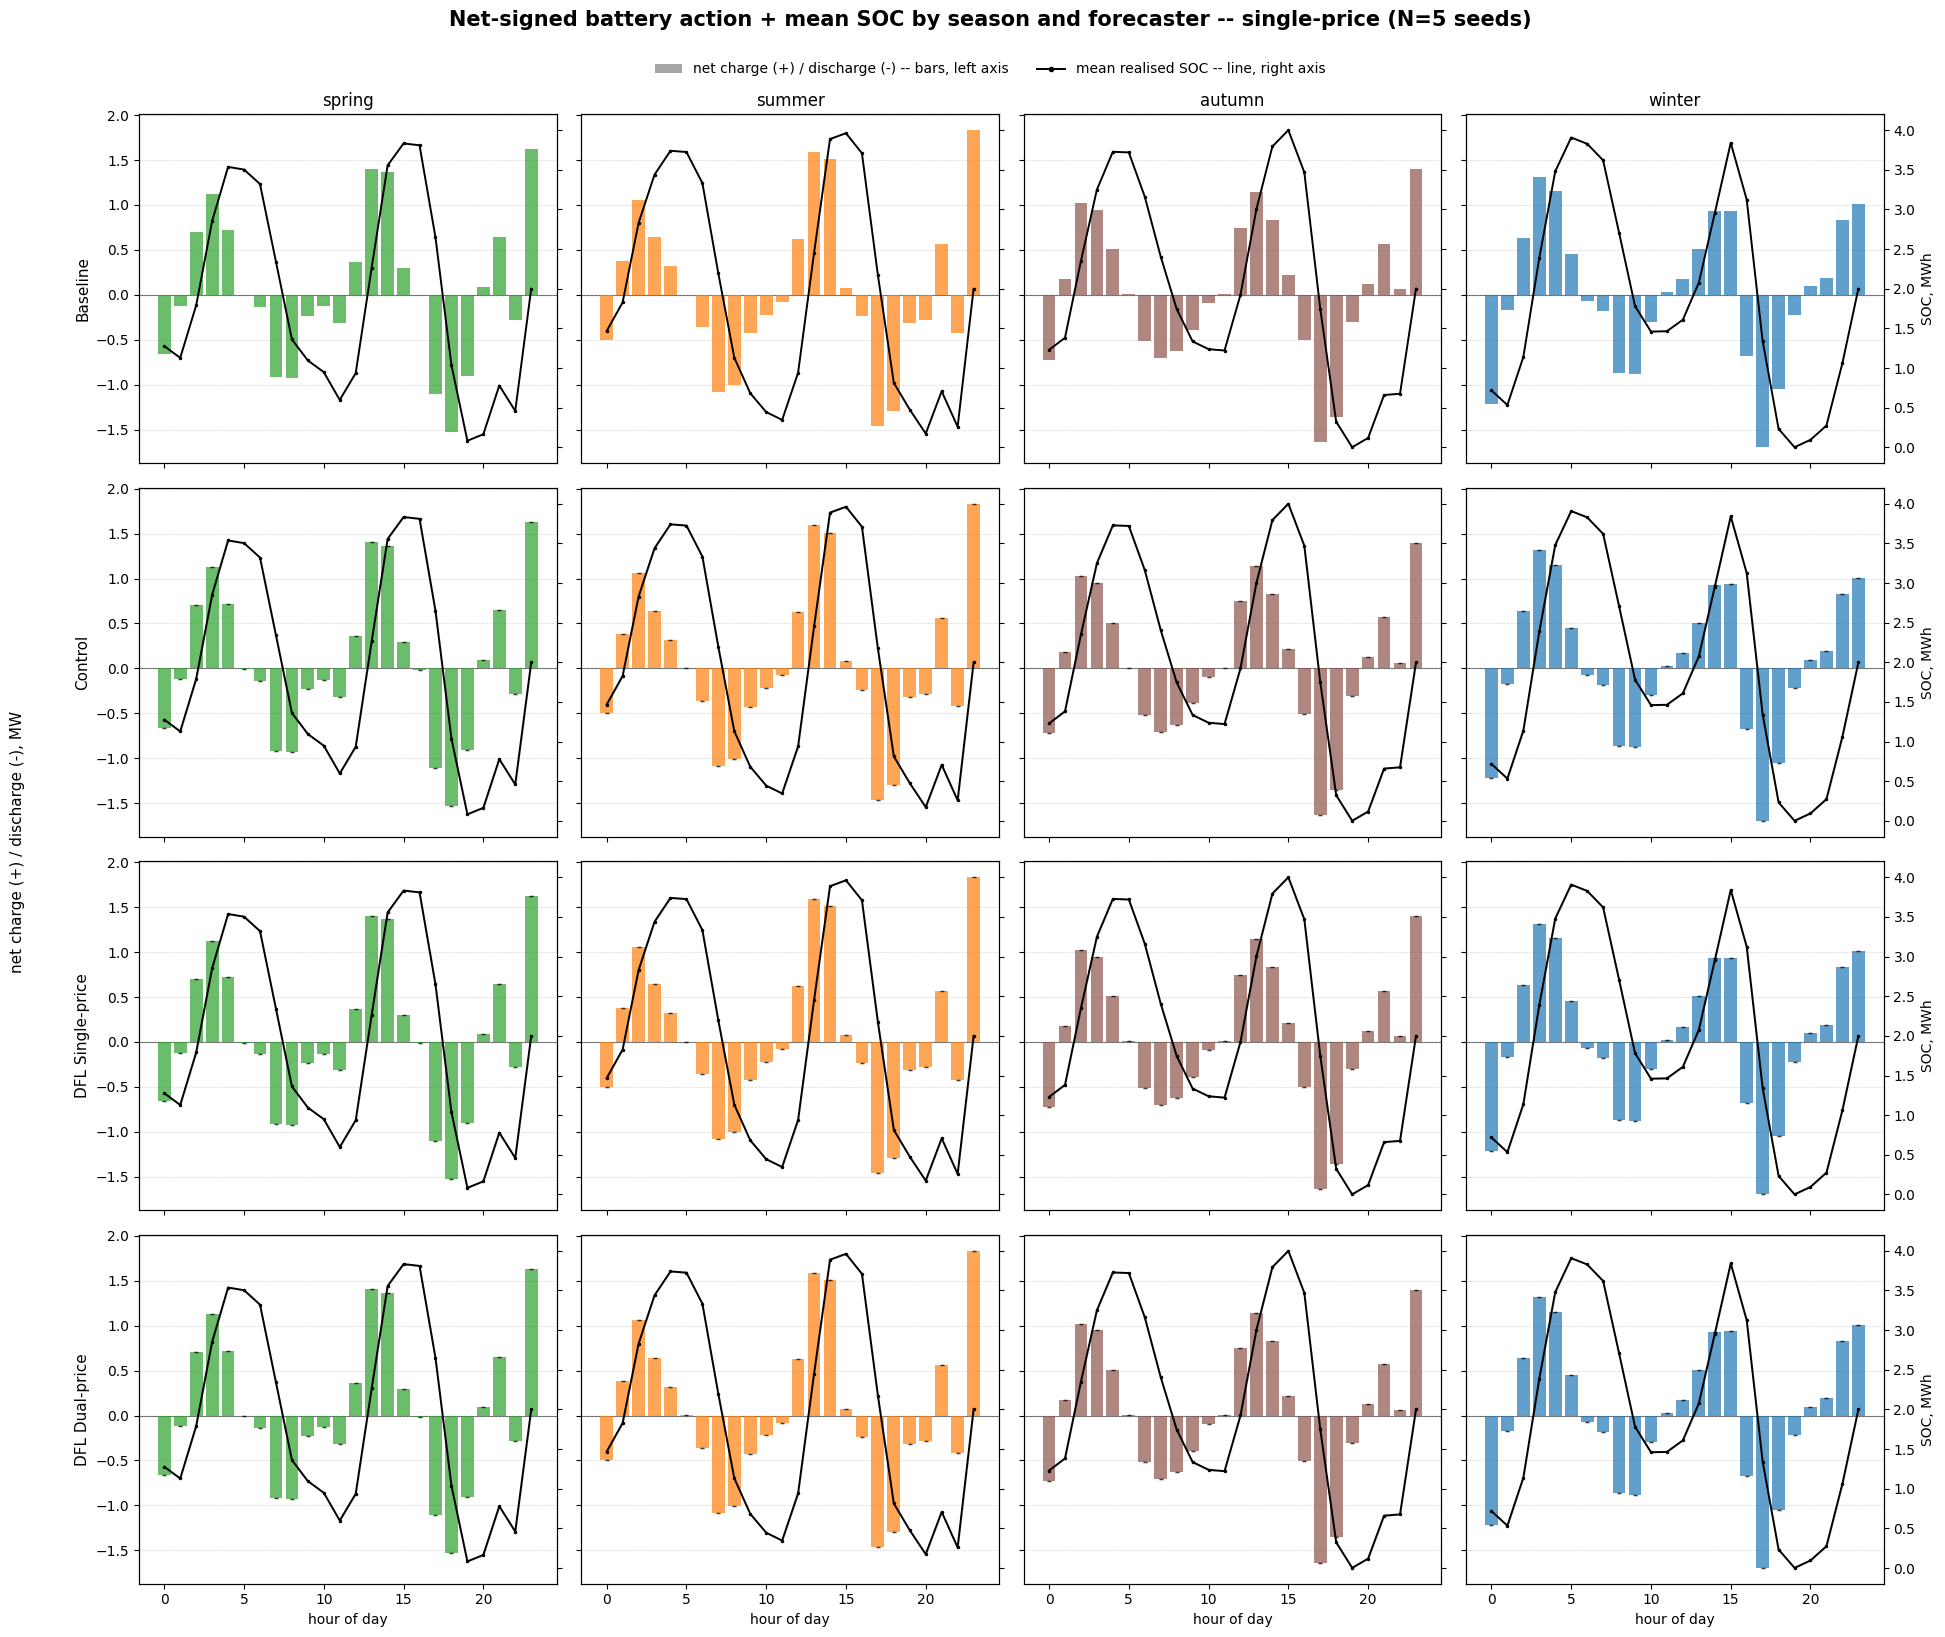

In [4]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

LEGEND_HANDLES = [
    Patch(facecolor="grey", alpha=0.7, label="net charge (+) / discharge (-) -- bars, left axis"),
    Line2D([0], [0], color="black", linewidth=1.4, marker=".", label="mean realised SOC -- line, right axis"),
]


def plot_market(market: str):
    fig, axes = plt.subplots(4, 4, figsize=(20, 16), sharex=True, sharey=True)
    h = np.arange(24)

    # unify the SOC (right-hand) axis scale across all 16 panels -- twinx() axes are not
    # covered by sharey=True, so this has to be done manually.
    soc_lo, soc_hi = np.inf, -np.inf
    for family in FAMILY_ORDER:
        for season in SEASON_ORDER:
            mean, std = RESULTS[(market, family)][season]["soc"]
            band = std if std is not None else 0.0
            soc_lo, soc_hi = min(soc_lo, (mean - band).min()), max(soc_hi, (mean + band).max())
    soc_pad = 0.05 * (soc_hi - soc_lo)

    for i, family in enumerate(FAMILY_ORDER):
        for j, season in enumerate(SEASON_ORDER):
            ax = axes[i, j]
            ax.axhline(0, color="black", linewidth=0.8, alpha=0.6, zorder=1)
            net_mean, net_std = RESULTS[(market, family)][season]["net"]
            ax.bar(h, net_mean, width=0.8, color=SEASON_COLORS[season], alpha=0.7,
                   yerr=net_std, error_kw=dict(elinewidth=0.8, ecolor="black", alpha=0.5, capsize=1.5),
                   zorder=2)
            ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

            ax2 = ax.twinx()
            soc_mean, soc_std = RESULTS[(market, family)][season]["soc"]
            ax2.plot(h, soc_mean, color="black", linewidth=1.4, marker=".", markersize=3, zorder=3)
            if soc_std is not None:
                ax2.fill_between(h, soc_mean - soc_std, soc_mean + soc_std, color="black", alpha=0.12, zorder=3)
            ax2.set_ylim(soc_lo - soc_pad, soc_hi + soc_pad)
            if j < 3:
                ax2.set_yticklabels([])
            else:
                ax2.set_ylabel("SOC, MWh", fontsize=10)

            if i == 0:
                ax.set_title(season, fontsize=12)
            if j == 0:
                ax.set_ylabel(family, fontsize=11)
            if i == 3:
                ax.set_xlabel("hour of day")

    fig.supylabel("net charge (+) / discharge (-), MW", fontsize=11, x=0.01)
    fig.legend(handles=LEGEND_HANDLES, loc="upper center", bbox_to_anchor=(0.5, 0.995), ncol=2, fontsize=10, frameon=False)
    fig.suptitle(f"Net-signed battery action + mean SOC by season and forecaster -- {market} (N=5 seeds)", fontsize=15, fontweight="bold", y=1.02)
    fig.tight_layout(rect=(0.02, 0, 0.98, 1))
    plt.show()


plot_market("single-price")

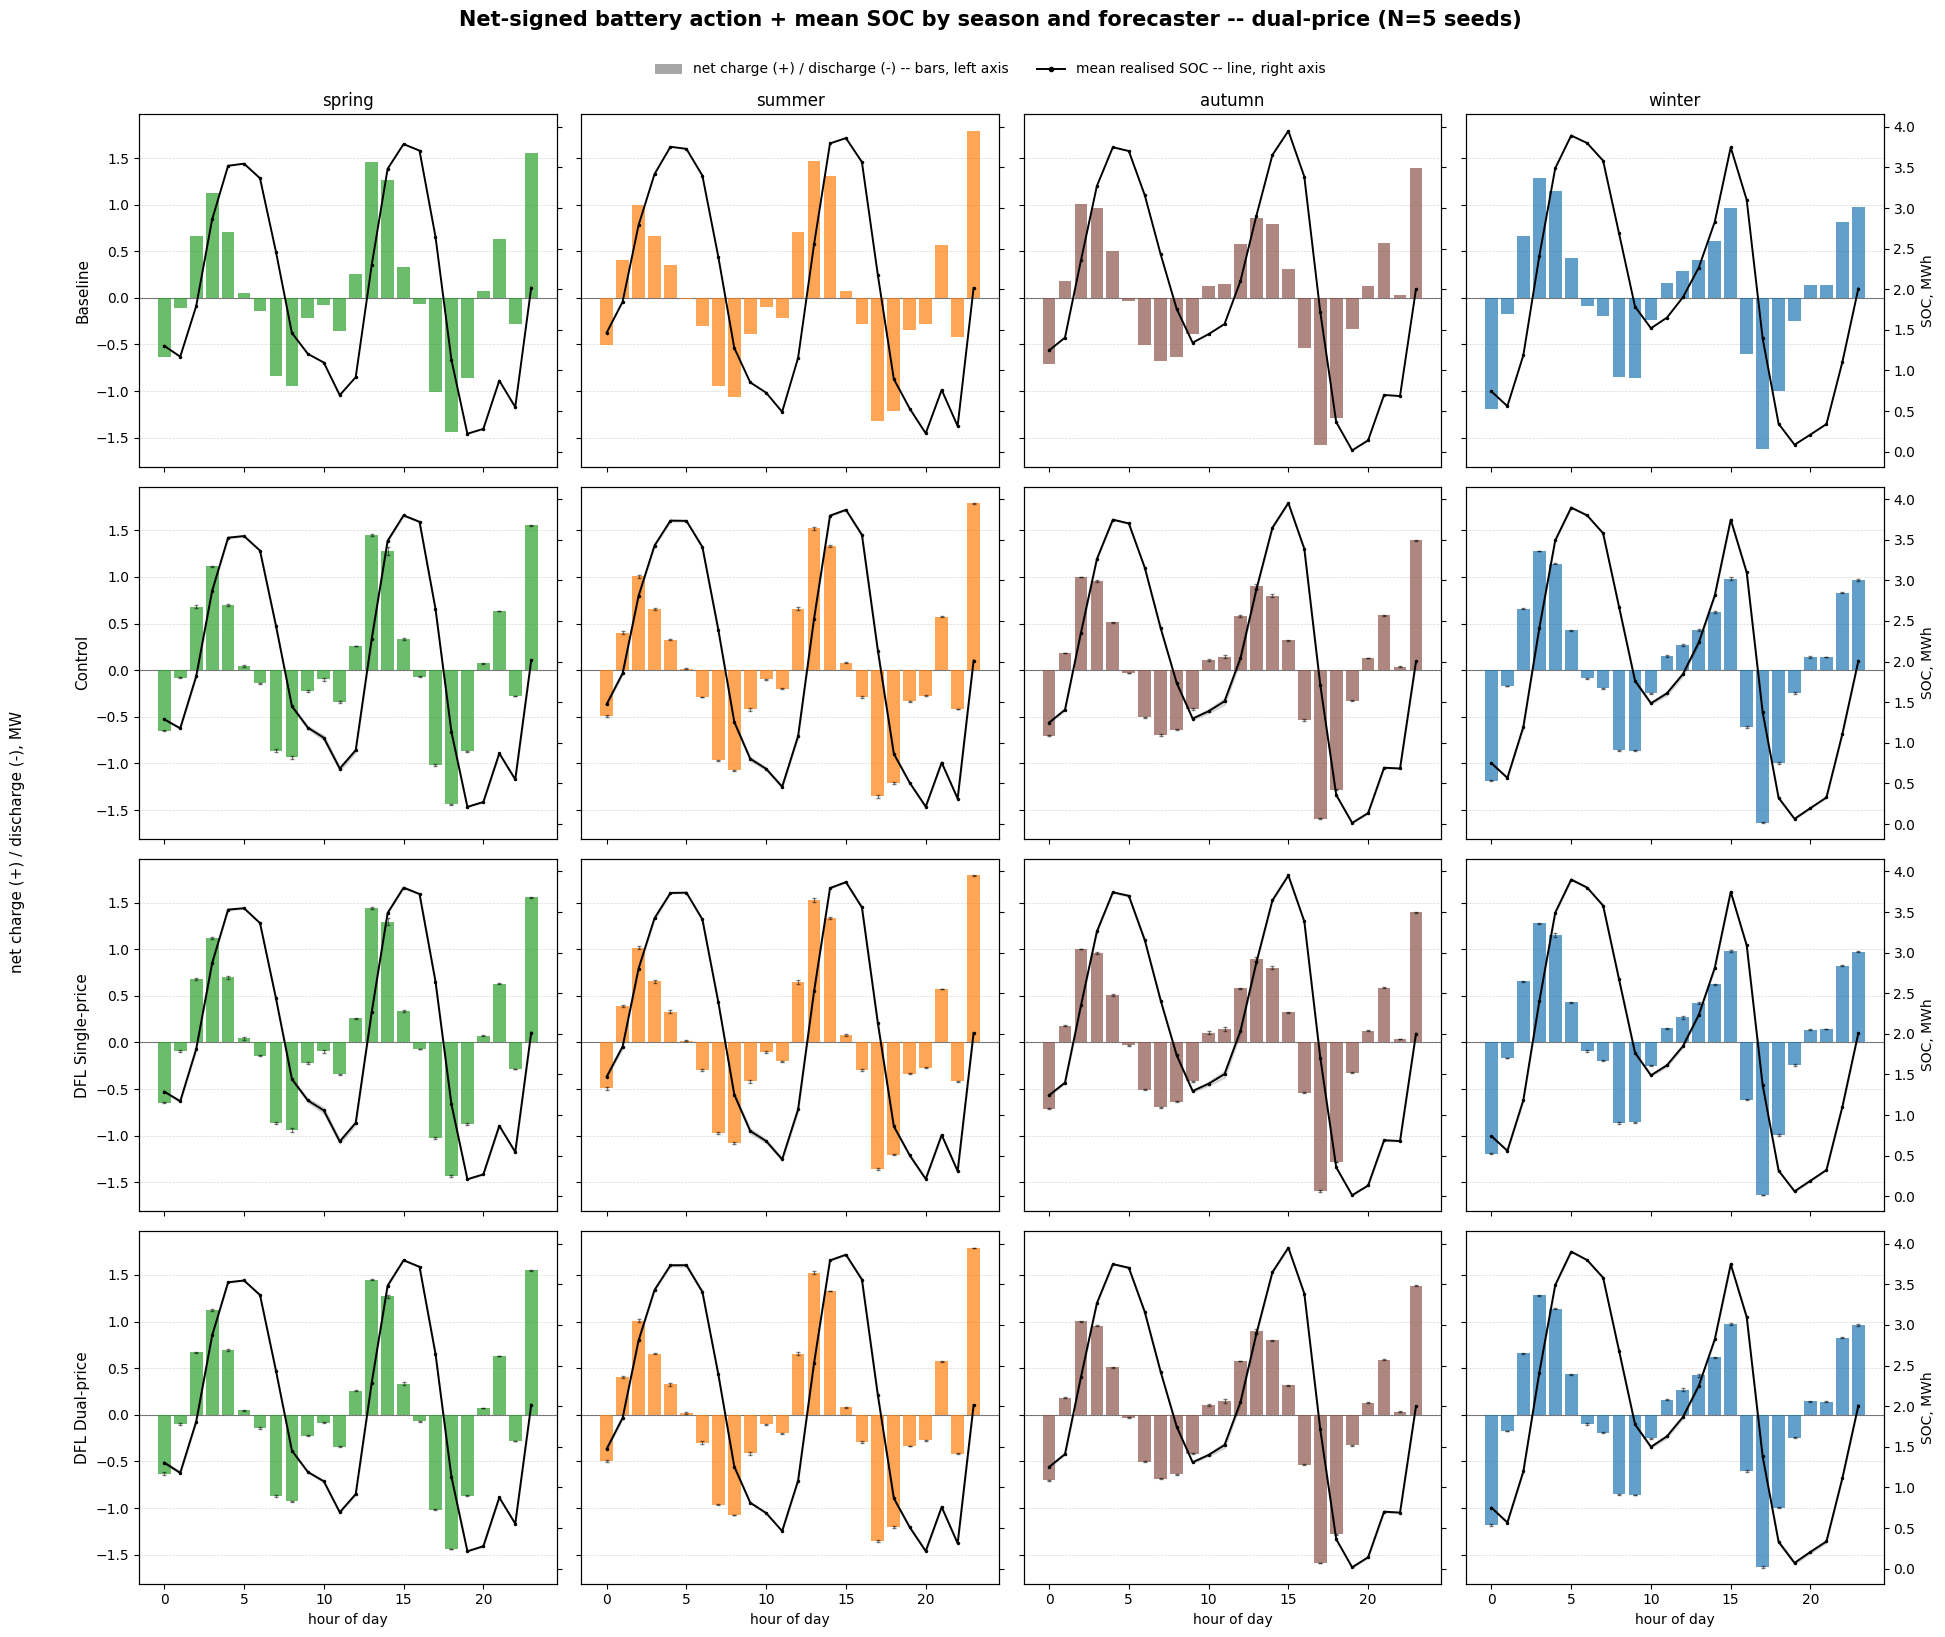

In [5]:
plot_market("dual-price")

## Baseline only: single-price vs. dual-price, all seasons side by side

Isolating the Baseline forecaster (the only one whose dispatch is directly comparable
across markets without any retraining confound) into one figure: top row is its
single-price evaluation, bottom row its dual-price evaluation, all four seasons left to
right in both rows. Unlike the net-signed figures above, charge and discharge are shown
**separately** here (`p_ch_r` as an upward bar, `p_dis_r` as a downward bar at the same
hour) rather than netted against each other -- this reveals any simultaneous
charge+discharge cycling within the same settlement hour that a net bar would hide, and
shows the true gross magnitude the battery is actually moving, not just its net effect.
Baseline is a single fixed checkpoint (n=1), so there are no seed error bars/shading here
-- this reuses the same `RESULTS` cache already collected above (extended with the raw
`"ch"`/`"dis"` profiles), no new aggregation needed.

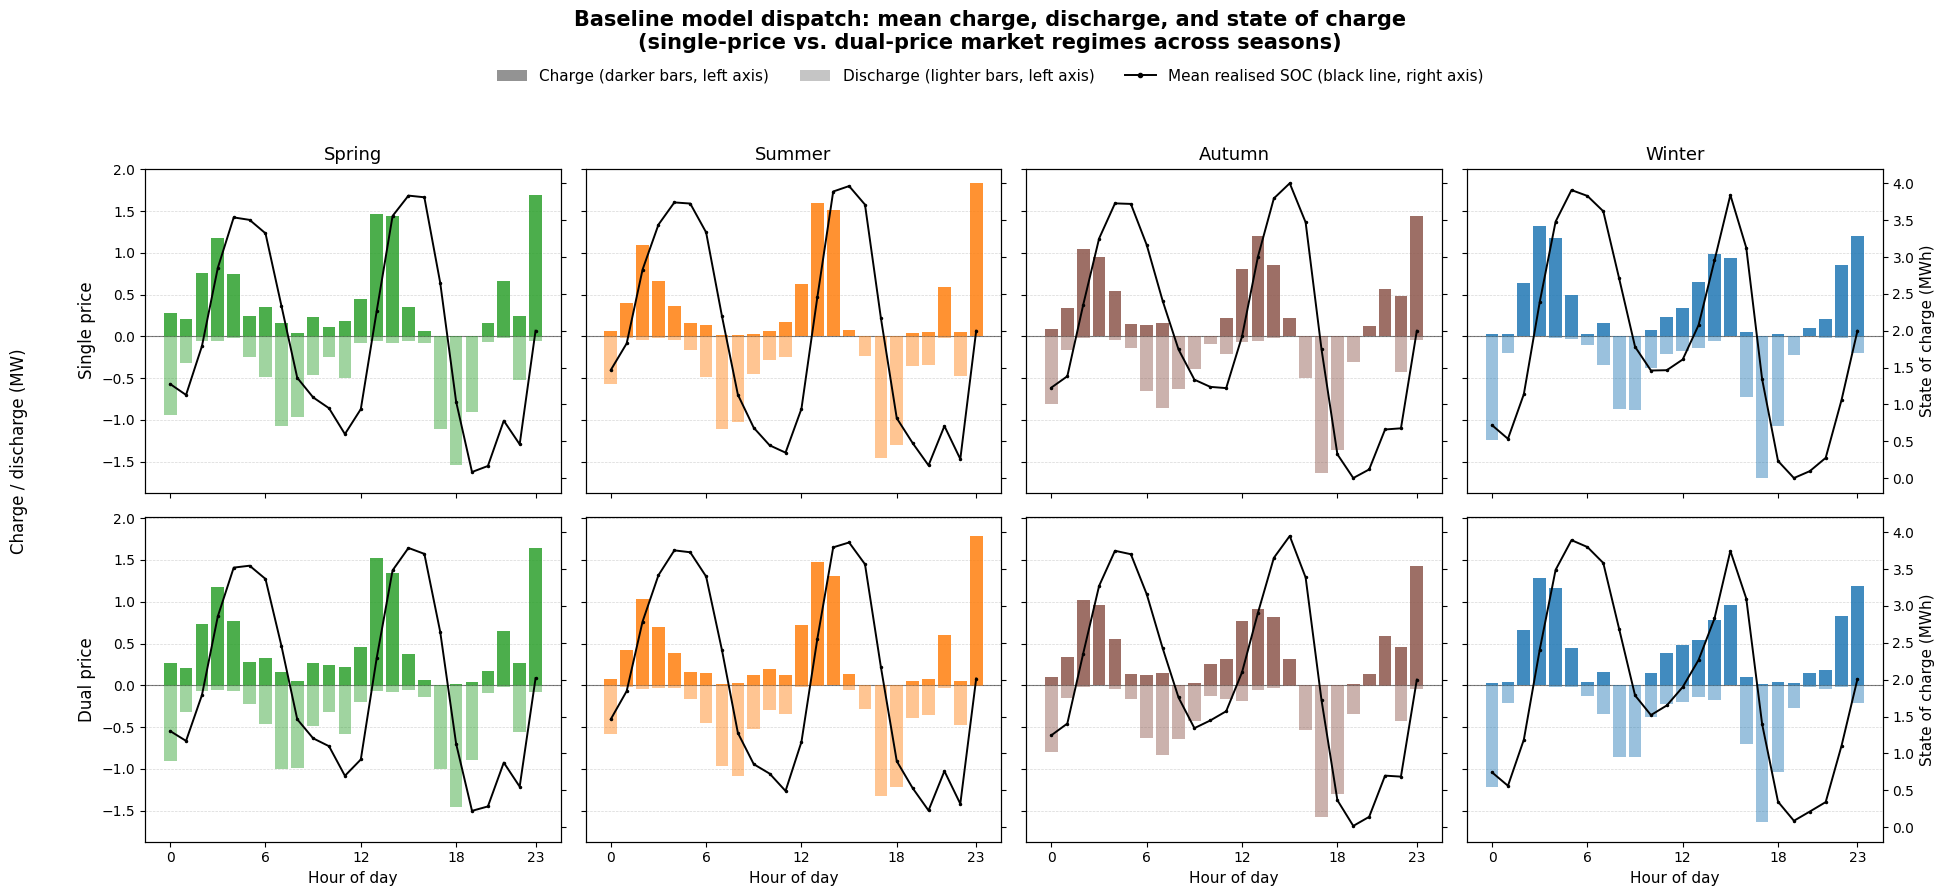

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def plot_baseline_comparison():
    markets = ["single-price", "dual-price"]
    fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharex=True, sharey=True)
    h = np.arange(24)

    # Unify the SOC (right-hand) axis scale across all 8 panels
    soc_lo, soc_hi = np.inf, -np.inf
    for market in markets:
        for season in SEASON_ORDER:
            mean, _ = RESULTS[(market, "Baseline")][season]["soc"]
            soc_lo, soc_hi = min(soc_lo, mean.min()), max(soc_hi, mean.max())
    soc_pad = 0.05 * (soc_hi - soc_lo)

    for i, market in enumerate(markets):
        for j, season in enumerate(SEASON_ORDER):
            ax = axes[i, j]
            ax.axhline(0, color="black", linewidth=0.8, alpha=0.6, zorder=1)
            
            ch_mean, _ = RESULTS[(market, "Baseline")][season]["ch"]
            dis_mean, _ = RESULTS[(market, "Baseline")][season]["dis"]
            
            ax.bar(h, ch_mean, width=0.8, color=SEASON_COLORS[season], alpha=0.85, zorder=2)
            ax.bar(h, -dis_mean, width=0.8, color=SEASON_COLORS[season], alpha=0.45, zorder=2)
            ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
            
            # 1. UPDATED: Set explicit x-axis ticks to represent logical times of day
            ax.set_xticks([0, 6, 12, 18, 23])

            # Secondary Axis (State of Charge)
            ax2 = ax.twinx()
            soc_mean, _ = RESULTS[(market, "Baseline")][season]["soc"]
            ax2.plot(h, soc_mean, color="black", linewidth=1.4, marker=".", markersize=3, zorder=3)
            ax2.set_ylim(soc_lo - soc_pad, soc_hi + soc_pad)
            
            if j < 3:
                ax2.set_yticklabels([])
            else:
                # 2. UPDATED: Expanded SOC acronym for clarity
                ax2.set_ylabel("State of charge (MWh)", fontsize=11)

            if i == 0:
                ax.set_title(season.capitalize(), fontsize=13)
            if j == 0:
                # Format market names cleanly (e.g., "Single-price")
                ax.set_ylabel(market.replace("-", " ").capitalize(), fontsize=12)
            if i == 1:
                ax.set_xlabel("Hour of day", fontsize=11)

    # 3. UPDATED: Simplified primary Y-axis label
    fig.supylabel("Charge / discharge (MW)", fontsize=12, x=0.01)

    # 4. UPDATED: Legend text changed to rely on shading ("darker/lighter") rather than color
    baseline_legend_handles = [
        Patch(facecolor="grey", alpha=0.85, label="Charge (darker bars, left axis)"),
        Patch(facecolor="grey", alpha=0.45, label="Discharge (lighter bars, left axis)"),
        Line2D([0], [0], color="black", linewidth=1.4, marker=".", label="Mean realised SOC (black line, right axis)"),
    ]
    
    # 5. UPDATED: Cleaned up legend placement and removed the frame for a cleaner look
    fig.legend(handles=baseline_legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=3, fontsize=11, frameon=False)
    
    # 6. UPDATED: Made the title formal and academic (removed the '+' and '--' syntax)
    fig.suptitle(
        "Baseline model dispatch: mean charge, discharge, and state of charge\n"
        "(single-price vs. dual-price market regimes across seasons)",
        fontsize=15, fontweight="bold", y=0.99
    )
    
    # 7. UPDATED: Adjusted rect to perfectly frame the new legend and title locations
    fig.tight_layout(rect=(0.02, 0, 0.98, 0.92))
    plt.show()

plot_baseline_comparison()